# What sequencing counts can and cannot tell you

*A narrative synthesis of three simulation notebooks: the
[Dirichlet-multinomial sampler](dirichlet-multinomial-simulation.ipynb), the
[identifiability experiments](dm-overexpression-identifiability.ipynb), and the
[clr and median-of-ratios field guide](clr-and-median-of-ratios-on-dm-counts.ipynb).
The figures below are live code and regenerate in about twenty seconds, so the post is
also runnable.*

**One-sentence version.** Sequencing gives you a noisy, renormalized sample of a
composition: it carries *relative* structure robustly, carries *absolute* structure not
at all, and every method that seems to hand you absolutes is quietly spending an
assumption. The point of this post is to make that assumption visible, because you are
the one paying for it.

**The cast.** A treatment that overexpresses a fraction $f$ of genes (ten percent to
sixty percent, factors of two to three, to keep things concrete). A matrix of integer
counts $y$, one library size $N$ per sample. And the four tools every analysis reaches
for: an honest variance model, the centered log-ratio transform, median-of-ratios
normalization, and spike-ins.

The flow: first the noise (Act I), then two impossibility results (the mirror trick,
the vanishing effect: Acts II and III), then the standard tools taken apart (Acts IV
and V), then a four-layer map of who does what, and a checklist to leave with.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from IPython.display import display

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20240614)
COL_A, COL_B, COL_M = "#4C72B0", "#DD8452", "#55A868"

print("numpy", np.__version__, "| seaborn", sns.__version__)

numpy 2.5.3 | seaborn 0.13.2


In [2]:
# ------------------------------------------------------------------------
# The toolbox: one small generator, reused by every figure below.
# (Appendix-style: skim past it; the acts start at the next markdown cell.)
# ------------------------------------------------------------------------
COL_A, COL_B, COL_M = "#4C72B0", "#DD8452", "#55A868"


def make_pi(K, rng, sigma=1.0, sort_descending=True):
    # base absolute abundances ~ lognormal (the "true" molecule mix)
    a = rng.lognormal(0.0, sigma, K)
    if sort_descending:
        a = np.sort(a)[::-1]
    return a / a.sum()


def fold_pi(pi, mask, factor):
    # multiply masked categories' absolute abundance, renormalize
    # returns (new composition, material multiplier C)
    m = np.ones(len(pi))
    m[mask] = factor
    pi2 = pi * m
    return pi2 / pi2.sum(), float(pi2.sum())


def mean_proportion(counts, N):
    return (counts / N[:, None]).mean(axis=0)


def simulate_group(pi, theta, n, census_factor=1.0, med_n=20_000, sigma_n=0.35,
                   rate_sigma=0.0, rng=None):
    # per sample: p_s ~ Dirichlet(theta * pi); N_s ~ LogNormal(log(med_n*census), sigma)
    # (optionally with per-sample sequencing-efficiency noise); counts ~ Multinomial
    P = np.vstack([rng.dirichlet(theta * pi) for _ in range(n)])
    scale = rng.lognormal(np.log(med_n * census_factor), sigma_n, n)
    if rate_sigma > 0:
        scale = scale * rng.lognormal(0.0, rate_sigma, n)
    N = np.round(scale).astype(int)
    counts = np.vstack([rng.multinomial(N[t], P[t]) for t in range(n)])
    return counts, N


def band_experiment(pi_b, pi_a, census_b, R, n, theta, rng, med_b=None):
    # repeat the two-group experiment R times; rows are per-gene log2 folds of
    # the mean observed proportions (B/A)
    med_b = 20_000 if med_b is None else med_b
    reps = np.empty((R, len(pi_a)))
    for r in range(R):
        ca, na_ = simulate_group(pi_a, theta, n, 1.0, 20_000, rng=rng)
        cb, nb_ = simulate_group(pi_b, theta, n, census_b, med_b, rng=rng)
        reps[r] = np.log2(mean_proportion(cb, nb_) / mean_proportion(ca, na_))
    return reps


def plot_band(ax, reps, col, label):
    med = np.median(reps, axis=0)
    q1, q3 = np.percentile(reps, [25, 75], axis=0)
    x = np.arange(reps.shape[1])
    ax.fill_between(x, q1, q3, color=col, alpha=0.22, lw=0)
    ax.plot(x, med, color=col, lw=1.8, label=label)


def clr(counts, pc):
    # centered log-ratio with multiplicative zero replacement (pseudocount pc)
    x = (counts + pc) / (counts + pc).sum(axis=1, keepdims=True)
    y = np.log(x)
    return y - y.mean(axis=1, keepdims=True)


def welch_reject(a, b, alpha=0.05):
    a, b = np.asarray(a, float), np.asarray(b, float)
    nA, nB = a.shape[0], b.shape[0]
    vA, vB = a.var(0, ddof=1), b.var(0, ddof=1)
    se2 = vA / nA + vB / nB
    df = se2 ** 2 / ((vA / nA) ** 2 / (nA - 1) + (vB / nB) ** 2 / (nB - 1) + 1e-300)
    tcrit = st.t.ppf(1 - alpha / 2, df)
    return np.abs((a.mean(0) - b.mean(0)) / np.sqrt(se2)) > tcrit


def mor_size_factors(counts):
    c = counts + 0.5
    geo = np.exp(np.log(c).mean(axis=0))
    return np.median(c / geo, axis=1)


# Act I testbed: per-gene z tests with naive vs Dirichlet-multinomial variance
def fpr_experiment(theta, K=100, n=30, R=40, med_n=20_000, sigma_n=0.3, rng=None,
                   with_clr=False):
    res = {"naive": [], "dm": [], "clr": []}
    for _ in range(R):
        pi = make_pi(K, rng, sigma=1.2, sort_descending=False)
        ca, na_ = simulate_group(pi, theta, n, 1.0, med_n, sigma_n, rng=rng)
        cb, nb_ = simulate_group(pi, theta, n, 1.0, med_n, sigma_n, rng=rng)  # null!
        pooled = (ca.sum(0) + cb.sum(0)) / (na_.sum() + nb_.sum())
        keep = pooled * (na_.mean() + nb_.mean()) >= 20        # expressible categories
        xA, xB = (ca / na_[:, None]).mean(0), (cb / nb_[:, None]).mean(0)
        p01 = pooled * (1.0 - pooled)
        with np.errstate(divide="ignore", invalid="ignore"):
            v_naive = p01 * (np.mean(1 / na_) + np.mean(1 / nb_)) / n
            v_dm = p01 * (np.mean((na_ + theta) / (na_ * (1 + theta)))
                          + np.mean((nb_ + theta) / (nb_ * (1 + theta)))) / n
        z_naive = np.abs(xB - xA) / np.sqrt(np.where(v_naive > 0, v_naive, np.inf))
        z_dm = np.abs(xB - xA) / np.sqrt(np.where(v_dm > 0, v_dm, np.inf))
        res["naive"].append((z_naive[keep] > 1.96).mean())
        res["dm"].append((z_dm[keep] > 1.96).mean())
        if with_clr:
            res["clr"].append(welch_reject(clr(cb, 0.5)[:, keep], clr(ca, 0.5)[:, keep]).mean())
    return {k: float(np.mean(v)) for k, v in res.items() if v}   # only computed keys

## Act I: the noise comes first

*Act I. The question: before asking what counts say about a treatment, agree on how counts behave at all.*

The generative model for gene, taxon or cell-type reads is the Dirichlet-multinomial. For
each sample $s$ from group $g(s)$:

$$
p_s \sim \operatorname{Dirichlet}(\theta\,\pi_{g(s)}),\qquad
N_s \sim \operatorname{LogNormal}(\log m_{g(s)},\,\sigma_N^2),\qquad
y_s \sim \operatorname{Multinomial}(N_s,\,p_s).
$$

A latent composition $p_s$ is drawn around its group's target $\pi_{g(s)}$ (the
concentration $\theta$ controls how tightly: small $\theta$ means wild compositions,
$\theta\to\infty$ recovers the plain multinomial), a total count $N_s$ is drawn, and the
reads are split among categories. We give the two groups *both* kinds of difference that
real studies have: different target compositions (the effect we want to discuss) and
different depth distributions (the nuisance we cannot avoid).

[[<matplotlib.axis.XTick at 0x71298da67d90>,
 [Text(0, 0, 'control'), Text(1, 0, 'treatment')],
 (-0.5, 1.5),
 (0.0, 112224.0),
 Text(0, 0.5, 'library size N'),
 Text(0.5, 1.0, 'Total counts differ across samples, and between groups')]

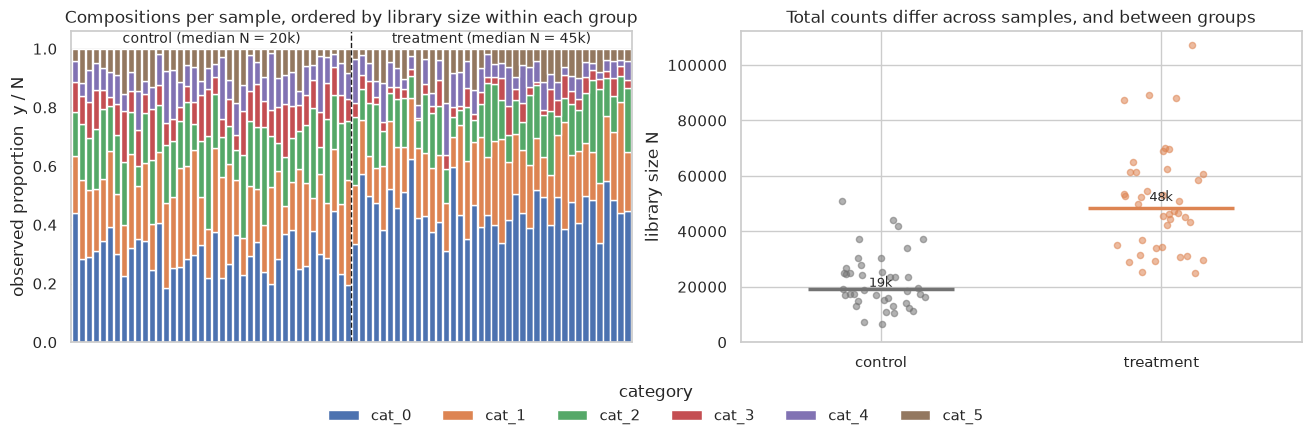

In [3]:
# Act I, figure 1: what the data actually look like
K1 = 6
CATEGORIES = [f"cat_{i}" for i in range(K1)]
PI = {"A": np.array([0.30, 0.25, 0.17, 0.10, 0.10, 0.08]),
      "B": np.array([0.45, 0.20, 0.15, 0.05, 0.08, 0.07])}

cntA, nA_ = simulate_group(PI["A"], 50.0, 40, med_n=20_000, rng=rng)
cntB, nB_ = simulate_group(PI["B"], 50.0, 40, med_n=45_000, rng=rng)
counts = np.vstack([cntA, cntB])
Ns = np.concatenate([nA_, nB_])
prop = counts / Ns[:, None]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.3), constrained_layout=True)
ax = axes[0]
bottom = np.zeros(len(prop))
for i in range(K1):
    ax.bar(np.arange(len(prop)), prop[:, i], bottom=bottom, width=0.92, label=CATEGORIES[i])
    bottom += prop[:, i]
ax.axvline(39.5, color="k", ls="--", lw=1)
ax.text(19.5, 1.02, "control (median N = 20k)", ha="center", fontsize=10)
ax.text(59.5, 1.02, "treatment (median N = 45k)", ha="center", fontsize=10)
ax.set(xlim=(-0.6, len(prop) - 0.4), ylim=(0, 1.06), xticks=[],
       ylabel="observed proportion  y / N",
       title="Compositions per sample, ordered by library size within each group")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc="outside lower center", frameon=False,
           title="category")

ax = axes[1]
for j, (lbl, v, col) in enumerate([("control", nA_, "0.45"), ("treatment", nB_, COL_B)]):
    ax.scatter(rng.uniform(j - 0.16, j + 0.16, len(v)), v, s=20, alpha=0.55, color=col)
    ax.hlines(np.median(v), j - 0.26, j + 0.26, color=col, lw=2.5)
    ax.text(j, np.median(v) * 1.05, f"{np.median(v)/1e3:.0f}k", ha="center", fontsize=9)
ax.set(xticks=[0, 1], xticklabels=["control", "treatment"], xlim=(-0.5, 1.5),
       ylim=(0, None), ylabel="library size N",
       title="Total counts differ across samples, and between groups")

Three things to notice. The between-group shift is plainly visible: category 0 rises
from 0.30 to 0.45. The per-sample compositions scatter widely around their group means:
at $\theta=50$ the latent proportions have sd $\sqrt{\pi(1-\pi)/(\theta+1)}$, about six
percentage points at $\pi=0.3$, large *relative to the effect itself*. And the library
sizes sprawl: the treatment here was simulated with 2.2 times the median depth, but
ordinary lab-yield variation produces the same picture.

The scatter is the whole show, and it has a closed form. The marginal variance of a
count is

$$
\operatorname{Var}(y_{si}) = N_s\,\pi_i(1-\pi_i)\,\frac{N_s+\theta}{1+\theta},
$$

and that last factor is exactly 1 for a multinomial and about 400 at $\theta=50$,
$N=20{,}000$. A two-group test that trusts the multinomial therefore understates its
variance by a factor of 400, and at $\alpha=0.05$ it flags, on data where **nothing at
all changed**:

theta = 1000: naive-variance FPR 0.66 | Dirichlet-multinomial-variance FPR 0.06
theta = 200: naive-variance FPR 0.85 | Dirichlet-multinomial-variance FPR 0.05


theta = 100: naive-variance FPR 0.89 | Dirichlet-multinomial-variance FPR 0.05
theta = 50: naive-variance FPR 0.92 | Dirichlet-multinomial-variance FPR 0.04


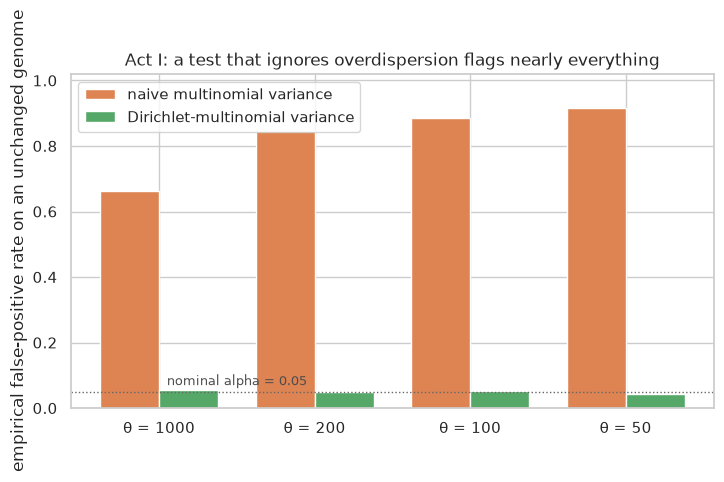

In [4]:
# Act I, figure 2: the naive variance is a false-positive machine
theta_grid = [1000.0, 200.0, 100.0, 50.0]
bars = {"naive": [], "dm": []}
for th in theta_grid:
    o = fpr_experiment(th, rng=rng)
    bars["naive"].append(o["naive"])
    bars["dm"].append(o["dm"])
    print(f"theta = {th:g}: naive-variance FPR {o['naive']:.2f} | "
          f"Dirichlet-multinomial-variance FPR {o['dm']:.2f}")

fig, ax = plt.subplots(figsize=(7.4, 4.2))
xx = np.arange(len(theta_grid))
ax.bar(xx - 0.19, bars["naive"], width=0.38, color=COL_B, label="naive multinomial variance")
ax.bar(xx + 0.19, bars["dm"], width=0.38, color=COL_M, label="Dirichlet-multinomial variance")
ax.axhline(0.05, color="0.4", ls=":", lw=1)
ax.text(0.05, 0.07, "nominal alpha = 0.05", color="0.3", fontsize=9)
ax.set(xticks=xx, xticklabels=[f"θ = {t:g}" for t in theta_grid], ylim=(0, 1.02),
       ylabel="empirical false-positive rate on an unchanged genome",
       title="Act I: a test that ignores overdispersion flags nearly everything")
ax.legend()
fig.tight_layout()

**Takeaway I.** *The noise floor is not a technicality bolted onto the end of an
analysis; it is the first object in it. Overdispersion-aware inference (beta-binomial,
Dirichlet-multinomial, per-gene negative-binomial GLMs, or plain empirical Welch
variances) is where every serious workflow begins. Keep this in view: every method that
survives the next three acts contains some version of this same fix inside it.*

## Act II: the mirror trick

*Act II. The question: the data show that compositions moved. Can we read the moves as "a fraction of the genes is overexpressed"?*

Now make the generative claim *absolute*. The treatment multiplies the true abundance of
a subset $U$ (a fraction $f$ of categories) by a factor $D$. The molecule pool grows by
the material multiplier

$$
C \;=\; 1 + \mu\,(D-1),\qquad \mu = \sum_{i\in U}\pi_i,
$$

and the new composition is $\pi^{B}_i = D^{\mathbb{1}[i\in U]}\,\pi_i / C$. Note that $\mu$
is *abundance-weighted*: picking the most abundant fifth of the categories moves more
than half the material, a detail that will matter in a moment. Now consider the **mirror
story**: leave $U$ alone and multiply the complement by $1/D$ in absolute terms.
Renormalize:

$$
\frac{\pi_i/D}{(1-\mu) + \mu/D} \;=\; \frac{D\,\pi_i}{1+\mu(D-1)} \qquad (i \in U),
$$

which is precisely the treatment story's composition. Two incompatible biological
claims, one identical composition, therefore one identical dataset. (The notebook
checks this numerically, to machine precision.)

overexpressed mass mu = 0.64 (f = 0.2 by category count)
material multiplier: treatment x2.27 | mirror x0.76
mirror identity (compositions identical): True


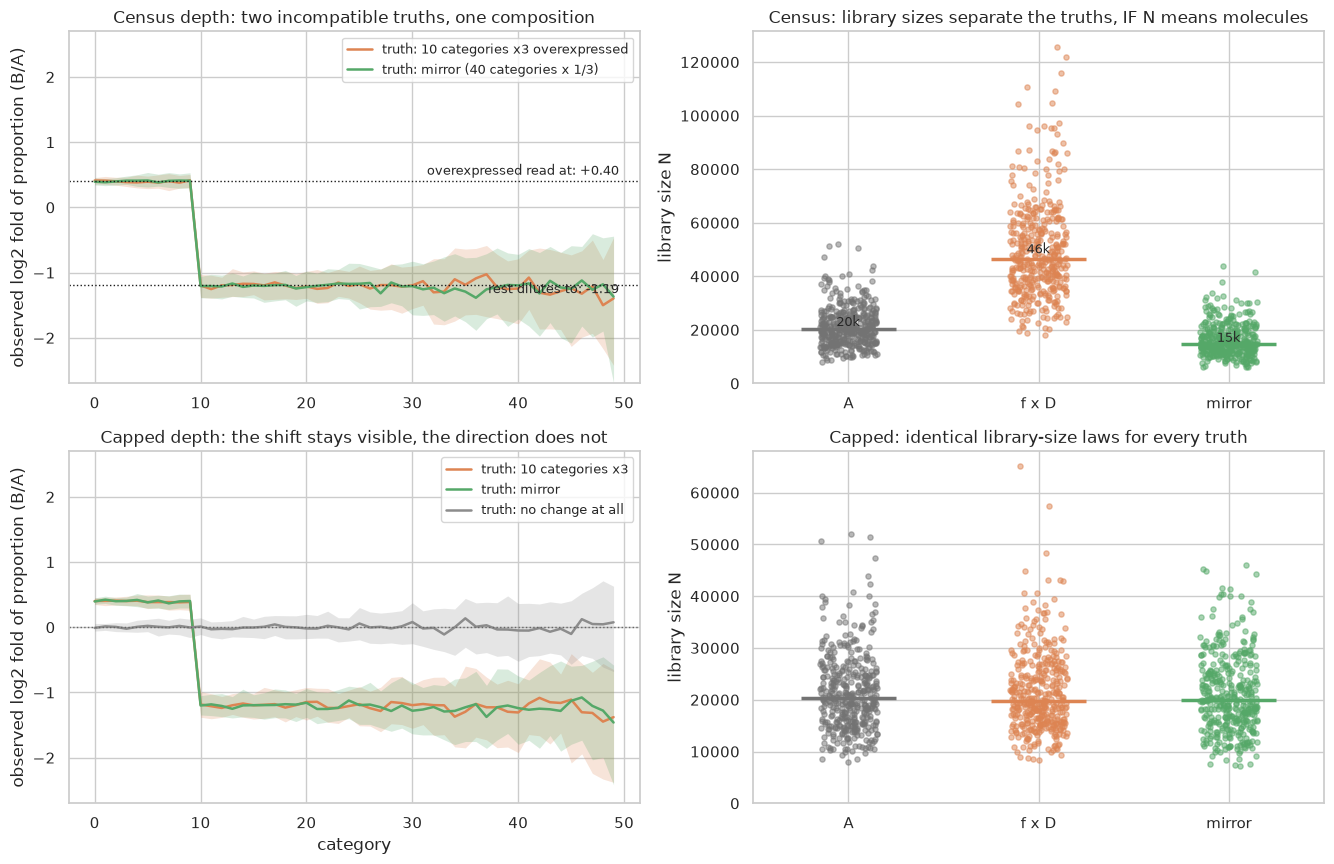

In [5]:
# Act II, figure 3: the mirror identity, under census and capped depth
Km = 50
pim = make_pi(Km, rng, sigma=1.2)                      # sorted descending
UP = np.arange(10)
W = ~np.isin(np.arange(Km), UP)
piT1, C1 = fold_pi(pim, UP, 3.0)                       # 10 categories overexpressed x3
piT2, C2 = fold_pi(pim, W, 1.0 / 3.0)                  # mirror: the other 40 x 1/3
mu = float(pim[UP].sum())
print(f"overexpressed mass mu = {mu:.2f} (f = 0.2 by category count)")
print(f"material multiplier: treatment x{C1:.2f} | mirror x{C2:.2f}")
print("mirror identity (compositions identical):", np.allclose(piT1, piT2, atol=1e-12))

reps_T1 = band_experiment(piT1, pim, C1, 150, 40, 100.0, rng)
reps_T2 = band_experiment(piT2, pim, C2, 150, 40, 100.0, rng)
reps_null = band_experiment(pim, pim, 1.0, 150, 40, 100.0, rng)
_, N_cens_A = simulate_group(pim, 100.0, 400, med_n=20_000, rng=rng)
_, N_cens_T1 = simulate_group(piT1, 100.0, 400, census_factor=C1, med_n=20_000, rng=rng)
_, N_cens_T2 = simulate_group(piT2, 100.0, 400, census_factor=C2, med_n=20_000, rng=rng)

reps_T1c = band_experiment(piT1, pim, 1.0, 150, 40, 100.0, rng)
reps_T2c = band_experiment(piT2, pim, 1.0, 150, 40, 100.0, rng)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.8))
ax = axes[0, 0]
plot_band(ax, reps_T1, COL_B, "truth: 10 categories x3 overexpressed")
plot_band(ax, reps_T2, COL_M, "truth: mirror (40 categories x 1/3)")
exp_up, exp_dn = np.log2(3.0 / C1), -np.log2(C1)
ax.axhline(exp_up, color="k", ls=":", lw=1)
ax.axhline(exp_dn, color="k", ls=":", lw=1)
ax.text(Km - 0.5, exp_up + 0.10, f"overexpressed read at: {exp_up:+.2f}", ha="right", fontsize=9)
ax.text(Km - 0.5, exp_dn - 0.13, f"rest dilutes to: {exp_dn:+.2f}", ha="right", fontsize=9)
ax.set(ylim=(-2.7, 2.7), ylabel="observed log2 fold of proportion (B/A)",
       title="Census depth: two incompatible truths, one composition")
ax.legend(loc="upper right", fontsize=9)

ax = axes[0, 1]
for j, (lbl, v, col) in enumerate([("A", N_cens_A, "0.45"), ("f x D", N_cens_T1, COL_B),
                                   ("mirror", N_cens_T2, COL_M)]):
    ax.scatter(rng.uniform(j - 0.15, j + 0.15, len(v)), v, s=14, alpha=0.5, color=col)
    ax.hlines(np.median(v), j - 0.25, j + 0.25, color=col, lw=2.5)
    ax.text(j, np.median(v) * 1.05, f"{np.median(v)/1e3:.0f}k", ha="center", fontsize=9)
ax.set(xticks=[0, 1, 2], xticklabels=["A", "f x D", "mirror"], xlim=(-0.5, 2.5),
       ylim=(0, None), ylabel="library size N",
       title="Census: library sizes separate the truths, IF N means molecules")

ax = axes[1, 0]
plot_band(ax, reps_T1c, COL_B, "truth: 10 categories x3")
plot_band(ax, reps_T2c, COL_M, "truth: mirror")
plot_band(ax, reps_null, "0.55", "truth: no change at all")
ax.axhline(0, color="0.4", ls=":", lw=1)
ax.set(ylim=(-2.7, 2.7), ylabel="observed log2 fold of proportion (B/A)",
       xlabel="category",
       title="Capped depth: the shift stays visible, the direction does not")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1, 1]
_, N_cap_T1 = simulate_group(piT1, 100.0, 400, med_n=20_000, rng=rng)
_, N_cap_T2 = simulate_group(piT2, 100.0, 400, med_n=20_000, rng=rng)
for j, (lbl, v, col) in enumerate([("A", N_cens_A, "0.45"), ("f x D", N_cap_T1, COL_B),
                                   ("mirror", N_cap_T2, COL_M)]):
    ax.scatter(rng.uniform(j - 0.15, j + 0.15, len(v)), v, s=14, alpha=0.5, color=col)
    ax.hlines(np.median(v), j - 0.25, j + 0.25, color=col, lw=2.5)
ax.set(xticks=[0, 1, 2], xticklabels=["A", "f x D", "mirror"], xlim=(-0.5, 2.5),
       ylim=(0, None), ylabel="library size N",
       title="Capped: identical library-size laws for every truth")

fig.tight_layout()

Read the figure like a detective story. Top left: the observed log2 fold changes of the
proportions, averaged over 150 replicated experiments, are *the same curve* for both
truths; the overexpressed categories read about $\log_2(D/C)$ and the rest dilute to
$-\log_2 C$. Top right: under the census assumption (reads proportional to molecules)
the two truths *do* separate, but only because we *chose* to read library size as
molecules; a change in sequencing efficiency is observationally the same signal. Bottom
row: under a capped instrument, library size is identical for every truth, and the two
stories become one dataset, full stop.

Something survives, and it matters: both stories remain cleanly separable from "no
change at all" (the grey band in the bottom left panel). Even with capped depth, the
counts can tell us that *the composition moved*. What they cannot tell us is *who moved
in absolute terms, and in which direction*.

**Takeaway II.** *Compositions are scale-free. "Overexpressed" is an absolute word. The
direction of a compositional shift is a property of the anchor you bring to the
analysis, not a property of the counts.*

## Act III: the vanishing effect

*Act III. The question: what if the treatment is even more extreme, and scales everything uniformly?*

A treatment that multiplies *every* gene by $c=2$ in absolute terms: the composition
barely twitches, because a uniform factor cancels under renormalization:

$$
\pi^{B}_i = \frac{c\,\pi_i}{c\sum_j \pi_j} = \pi_i \qquad \text{for all } i.
$$

Three stories, one dataset:

largest |median fold| across categories: G1 0.151, G2 0.129, G3 0.111
G1 vs G2: indistinguishable (a global expression change vs faster sequencing);
G3 vs 'no change': indistinguishable (a global expression change vs nothing at all).


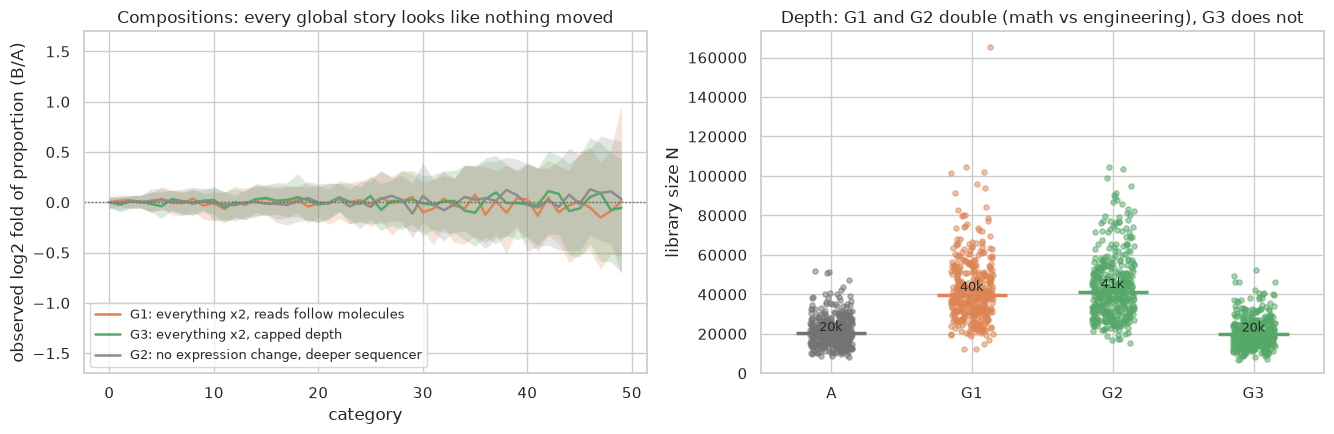

In [6]:
# Act III, figure 4: the vanishing effect
piG, CG = fold_pi(pim, np.ones(Km, dtype=bool), 2.0)   # composition unchanged, material x2
reps_G1 = band_experiment(piG, pim, CG, R=120, n=40, theta=100.0, rng=rng)
reps_G2 = band_experiment(pim, pim, 1.0, R=120, n=40, theta=100.0, rng=rng, med_b=40_000)
reps_G3 = band_experiment(piG, pim, 1.0, R=120, n=40, theta=100.0, rng=rng)
_, NG1 = simulate_group(piG, 100.0, 400, census_factor=CG, med_n=20_000, rng=rng)
_, NG2 = simulate_group(pim, 100.0, 400, med_n=40_000, rng=rng)
_, NG3 = simulate_group(piG, 100.0, 400, med_n=20_000, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
ax = axes[0]
plot_band(ax, reps_G1, COL_B, "G1: everything x2, reads follow molecules")
plot_band(ax, reps_G3, COL_M, "G3: everything x2, capped depth")
plot_band(ax, reps_G2, "0.55", "G2: no expression change, deeper sequencer")
ax.axhline(0, color="0.4", ls=":", lw=1)
ax.set(xlabel="category", ylim=(-1.7, 1.7), ylabel="observed log2 fold of proportion (B/A)",
       title="Compositions: every global story looks like nothing moved")
ax.legend(loc="lower left", fontsize=9)

ax = axes[1]
pairs = [("A", N_cens_A, "0.45"), ("G1", NG1, COL_B), ("G2", NG2, COL_M), ("G3", NG3, COL_M)]
for j, (lbl, v, col) in enumerate(pairs):
    ax.scatter(rng.uniform(j - 0.15, j + 0.15, len(v)), v, s=14, alpha=0.5, color=col)
    ax.hlines(np.median(v), j - 0.25, j + 0.25, color=col, lw=2.5)
    ax.text(j, np.median(v) * 1.05, f"{np.median(v)/1e3:.0f}k", ha="center", fontsize=9)
ax.set(xticks=range(4), xticklabels=[p[0] for p in pairs], xlim=(-0.5, 3.5), ylim=(0, None),
       ylabel="library size N",
       title="Depth: G1 and G2 double (math vs engineering), G3 does not")

fig.tight_layout()

mx = np.abs(np.median(reps_G1, axis=0)).max(), np.abs(np.median(reps_G2, axis=0)).max(), \
    np.abs(np.median(reps_G3, axis=0)).max()
print(f"largest |median fold| across categories: G1 {mx[0]:.3f}, G2 {mx[1]:.3f}, G3 {mx[2]:.3f}")
print("G1 vs G2: indistinguishable (a global expression change vs faster sequencing);")
print("G3 vs 'no change': indistinguishable (a global expression change vs nothing at all).")

**Takeaway III.** *Uniform abundance changes are stories about the absolute pool. The
composition channel is blind to them by arithmetic. The depth channel moves, but it
cannot explain itself: "material doubled" and "the instrument got faster" are the same
dataset. A global up-regulation is visible only to an external calibration, never to the
counts alone.*

---

*A short pause, because this is the point where every real analysis reaches for two
standard tools: log-ratio coordinates (clr, ILR; ANCOM and ALDEx2 in the microbiome
world) and library-size normalization (median-of-ratios in DESeq2, TMM in edgeR,
deconvolution pools in scran). Both are good tools. The only question worth asking is
what they change about Acts II and III. The next two acts take each apart.*

## Act IV: the clr transform, field-tested

*Act IV. The question: does re-expressing the counts in log-ratio coordinates change what we can know?*

The centered log-ratio transform of a composition $x$ is

$$
\mathrm{clr}_i(x) = \log x_i - \frac{1}{K}\sum_{j=1}^{K}\log x_j,
$$

a bijection from the simplex to the sum-zero hyperplane. It does two things at once, and
it is worth being precise about which.

**It is a coordinate system plus a built-in anchor.** The difference of clr values
between two conditions is

$$
\mathrm{clr}_i(\pi^{B}) - \mathrm{clr}_i(\pi^{A})
= \log\frac{\pi^{B}_i}{\pi^{A}_i} - \frac{1}{K}\sum_{j}\log\frac{\pi^{B}_j}{\pi^{A}_j},
$$

which is exactly the gene's fold change *measured against the geometric mean of all
genes' fold changes*. That is an anchor-relative statement, with the geometric mean as
the anchor. Act V will do the same thing with a count-median anchor. In other words: clr
has not escaped the identifiability problem, it has *given it coordinates* (a bijection
cannot create information; the mirror and the vanishing effect walk straight through
clr-space untouched).

**It also defines where the distributional question lives.** If your data model lives in
clr coordinates, then your model of a composition should be a distribution on that
hyperplane, and the standard choice is the logistic-normal: $\eta \sim \mathcal N(\mu,
\Sigma)$ with $p = \operatorname{softmax}(\eta)$. This is not pedantry. The Dirichlet is
structurally rigid in log space: *every* pair of log-compositions is negatively
correlated by the same constant, $\operatorname{Cov}(\log p_i,\log p_j) =
-\psi'(\alpha_0)$, so the Dirichlet cannot express co-regulation at all. The
logistic-normal can:

closed form (Dirichlet): Var(log p_i) = psi'(alpha_i) - psi'(alpha0), Cov(log p_i, log p_j) = -psi'(alpha0) for i != j
the logistic-normal (softmax of a Gaussian, i.e. Gaussian clr) can express blocks of
co-occurring categories; the Dirichlet structurally cannot.


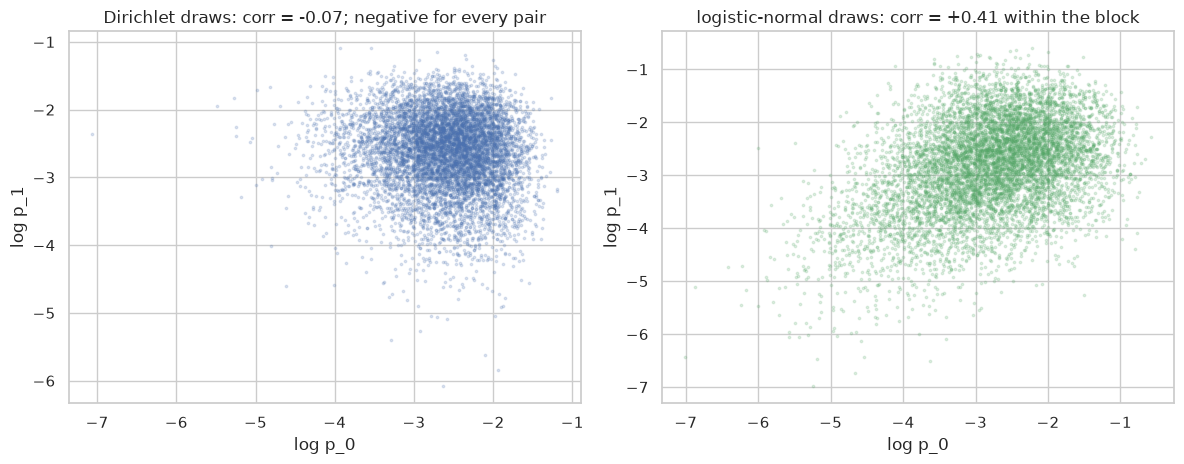

In [7]:
# Act IV, figure 5: Dirichlet's rigid log-geometry vs the logistic-normal
THl, Kl = 40.0, 12
pil = np.full(Kl, 1.0 / Kl)
logP = np.log(np.vstack([rng.dirichlet(THl * pil) for _ in range(40_000)]))
Sig = np.full((Kl, Kl), -0.05)
Sig[:6, :6] = 0.55
Sig[6:, 6:] = 0.55
np.fill_diagonal(Sig, 1.0)
np.linalg.cholesky(Sig)                       # positive-definite check
eta = rng.multivariate_normal(np.zeros(Kl), Sig, size=8000)
eta -= eta.max(axis=1, keepdims=True)
P_ln = np.exp(eta) / np.exp(eta).sum(axis=1, keepdims=True)
logP_ln = np.log(P_ln)

c_dm = np.corrcoef(logP[:8000], rowvar=False)[0, 1]
c_ln = np.corrcoef(logP_ln, rowvar=False)[0, 1]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
axes[0].scatter(logP[:8000, 0], logP[:8000, 1], s=3, alpha=0.18, color=COL_A)
axes[0].set(xlabel="log p_0", ylabel="log p_1",
            title=f"Dirichlet draws: corr = {c_dm:+.2f}; negative for every pair")
axes[1].scatter(logP_ln[:, 0], logP_ln[:, 1], s=3, alpha=0.18, color=COL_M)
axes[1].set(xlabel="log p_0", ylabel="log p_1",
            title=f"logistic-normal draws: corr = {c_ln:+.2f} within the block")
fig.tight_layout()
print("closed form (Dirichlet): Var(log p_i) = psi'(alpha_i) - psi'(alpha0), "
      "Cov(log p_i, log p_j) = -psi'(alpha0) for i != j")
print("the logistic-normal (softmax of a Gaussian, i.e. Gaussian clr) can express blocks of")
print("co-occurring categories; the Dirichlet structurally cannot.")

**And an operational constraint: zeros.** The multinomial produces them for free; clr is
undefined at $x_i = 0$. Overdispersed sparse data are *full* of zeros, so every clr
pipeline replaces them, and because the replacement is arbitrary, the estimate becomes
arbitrary too. Below: one rare category ($\pi = 10^{-3}$, about 30 counts per sample at
$N = 30{,}000$), overexpressed ×20 in absolute terms; most samples draw its latent
proportion near zero, so about half the control counts are 0. Fifteen replicated
experiments per pseudocount:

representative replicate: zero rate for the rare category: A 47%, B 0%
  clr, pseudocount    0.5: median +4.97
  clr, pseudocount      2: median +4.16
  clr, pseudocount     10: median +3.09
  clr, pseudocount     50: median +1.98
  clr, pseudocount    200: median +1.09
  prop-ratio (count model): median +4.24 (truth +4.29)


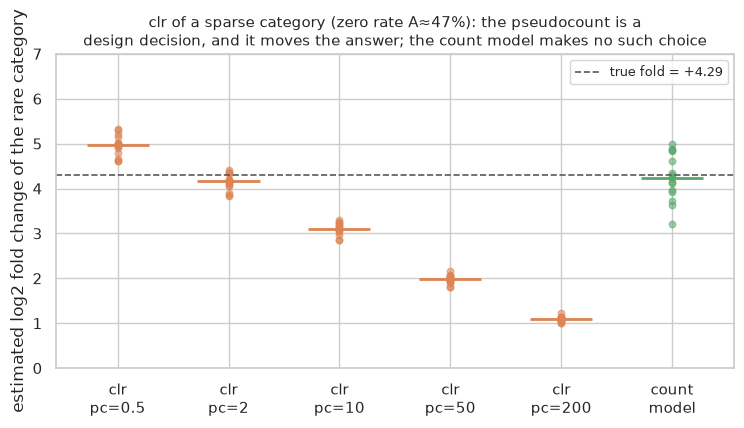

In [8]:
# Act IV, figure 6: a sparse category and clr: the pseudocount decides the answer
Kz, RARE, Dz = 20, 19, 20.0
piz = make_pi(Kz, rng, sigma=0.9)
piz[RARE] = 1e-3
piz /= piz.sum()
mz = np.zeros(Kz, bool)
mz[RARE] = True
piBz, Cz = fold_pi(piz, mz, Dz)
cntAz, na_ = simulate_group(piz, 100.0, 60, med_n=30_000, sigma_n=0.30, rng=rng)
cntBz, nb_ = simulate_group(piBz, 100.0, 60, census_factor=Cz, med_n=30_000, sigma_n=0.30, rng=rng)
zA_ = (cntAz[:, RARE] == 0).mean()
zB_ = (cntBz[:, RARE] == 0).mean()
print(f"representative replicate: zero rate for the rare category: A {zA_:.0%}, B {zB_:.0%}")

R2, n2, pcs = 15, 120, [0.5, 2, 10, 50, 200]
ests = {pc: [] for pc in pcs}
props = []
for _ in range(R2):
    a2, na2 = simulate_group(piz, 100.0, n2, med_n=30_000, sigma_n=0.30, rng=rng)
    b2, nb2 = simulate_group(piBz, 100.0, n2, census_factor=Cz, med_n=30_000, sigma_n=0.30, rng=rng)
    for pc in ests:
        ests[pc].append(clr(b2, pc).mean(0)[RARE] - clr(a2, pc).mean(0)[RARE])
    props.append(float(np.log2(mean_proportion(b2, nb2)[RARE] / mean_proportion(a2, na2)[RARE])))

truth_6 = np.log2(piBz[RARE] / piz[RARE])
for pc in ests:
    print(f"  clr, pseudocount {pc:>6g}: median {np.median(ests[pc]):+.2f}")
print(f"  prop-ratio (count model): median {np.median(props):+.2f} "
      f"(truth {truth_6:+.2f})")

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for j, (pc, vals) in enumerate(ests.items()):
    ax.scatter(np.full(R2, j), vals, s=22, alpha=0.55, color=COL_B)
    ax.hlines(np.median(vals), j - 0.28, j + 0.28, color=COL_B, lw=2)
ax.scatter(np.full(R2, len(pcs)), props, s=22, alpha=0.55, color=COL_M)
ax.hlines(np.median(props), len(pcs) - 0.28, len(pcs) + 0.28, color=COL_M, lw=2)
ax.axhline(truth_6, color="0.35", ls="--", lw=1.2, label=f"true fold = {truth_6:+.2f}")
ax.set(xticks=list(range(len(pcs) + 1)),
       xticklabels=[f"clr\npc={pc:g}" for pc in pcs] + ["count\nmodel"],
       ylim=(0, 7), ylabel="estimated log2 fold change of the rare category")
ax.set_title(f"clr of a sparse category (zero rate A≈{zA_:.0%}): the pseudocount is a\n"
             "design decision, and it moves the answer; the count model makes no such choice",
             fontsize=11)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()

**Finally, the calibration reminder, because it is the Act I lesson wearing a transform
costume.** Feeding counts into clr and running a vanilla test buys *nothing* by itself:
the transform neither knows nor cares about overdispersion. What does the work is
variance: either the **empirical across-sample variance** of a Welch t-test (which
silently contains the Dirichlet spread, since sample compositions really do scatter;
this is the ALDEx2 recipe: Dirichlet Monte-Carlo draws, then clr, then Welch), or an
**explicit overdispersed variance** such as the DM's
$\frac{N+\theta}{N(1+\theta)}\,p_i(1-p_i)$. Three procedures, same null as Act I
(identical compositions, $\alpha = 0.05$):

theta = 1000: naive 0.66 | DM-variance 0.05 | Welch t on clr 0.04
theta = 200: naive 0.84 | DM-variance 0.05 | Welch t on clr 0.05


theta = 100: naive 0.89 | DM-variance 0.04 | Welch t on clr 0.05
theta = 50: naive 0.92 | DM-variance 0.04 | Welch t on clr 0.05


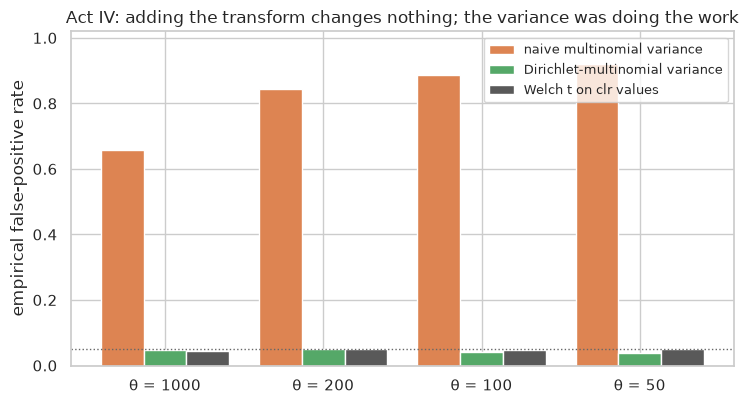

In [9]:
# Act IV, figure 7: the transform is neutral; the variance model decides
theta_grid = [1000.0, 200.0, 100.0, 50.0]
rows7 = {"naive": [], "dm": [], "clr": []}
for th in theta_grid:
    o = fpr_experiment(th, rng=rng, with_clr=True)
    for k in rows7:
        rows7[k].append(o[k])
    print(f"theta = {th:g}: naive {o['naive']:.2f} | DM-variance {o['dm']:.2f} | "
          f"Welch t on clr {o['clr']:.2f}")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
xx = np.arange(len(theta_grid))
w = 0.27
for k, (key, lbl, col) in enumerate(zip(
        ["naive", "dm", "clr"],
        ["naive multinomial variance", "Dirichlet-multinomial variance", "Welch t on clr values"],
        [COL_B, COL_M, "0.35"])):
    ax.bar(xx + (k - 1) * w, rows7[key], width=w, color=col, label=lbl)
ax.axhline(0.05, color="0.4", ls=":", lw=1)
ax.set(xticks=xx, xticklabels=[f"θ = {t:g}" for t in theta_grid], ylim=(0, 1.02),
       ylabel="empirical false-positive rate",
       title="Act IV: adding the transform changes nothing; the variance was doing the work")
ax.legend(fontsize=9)
fig.tight_layout()

**Takeaway IV.** *A transform buys coordinates and a default anchor. It does not buy
noise handling, calibration, or the absolute scale, and where data are sparse it
introduces a free parameter it cannot defend (the pseudocount). For distributional work
in clr space, the honest analog of the Dirichlet-multinomial is the
logistic-normal(-multinomial), flexible and Gaussian, not the rigid Dirichlet.*

## Act V: median-of-ratios, field-tested

*Act V. The question: does normalizing the library sizes change what we can know?*

DESeq2's size factors are

$$
s_s = \mathrm{median}_i\,\frac{y_{si}+0.5}{g_i},\qquad
g_i = \Bigl(\prod_{t} y_{ti}\Bigr)^{\!1/T},
$$

with $g_i$ the geometric mean of gene $i$ across samples (genes with a zero geometric
mean are excluded from the median; note how zero-friendly this is next to clr). The
per-gene contrasts then behave like

$$
\widehat{\mathrm{LFC}}_i \;\approx\; \underbrace{\log_2 \frac{\pi^{B}_i}{\pi^{A}_i}}_{\text{composition fold}} \;+\; \log_2\frac{s_A}{s_B}
\;=\; \log_2 m_i \;-\; \log_2(\text{anchor fold}),
$$

an **anchor-relative** fold change: it equals the absolute expression fold $m_i$ if and
only if the anchor class (the median gene, roughly the majority) did not move in
absolute terms. The demonstration, with per-sample sequencing-efficiency noise $e_s$,
so that library sizes vary for *rate* reasons as well as *material* reasons:

f = 0.1 of genes: material multiplier C = 1.18 | median N: A 32k, B 37k (nominal 35k) | 459 of 500 genes expressible
    raw: overexpressed +2.25 | unchanged -0.14
  depth: overexpressed +1.46 | unchanged -0.25
    MoR: overexpressed +1.58 | unchanged -0.05
f = 0.6 of genes: material multiplier C = 2.26 | median N: A 30k, B 65k (nominal 68k) | 468 of 500 genes expressible
    raw: overexpressed +1.47 | unchanged -0.91
  depth: overexpressed +0.41 | unchanged -1.18
    MoR: overexpressed +1.44 | unchanged -0.13


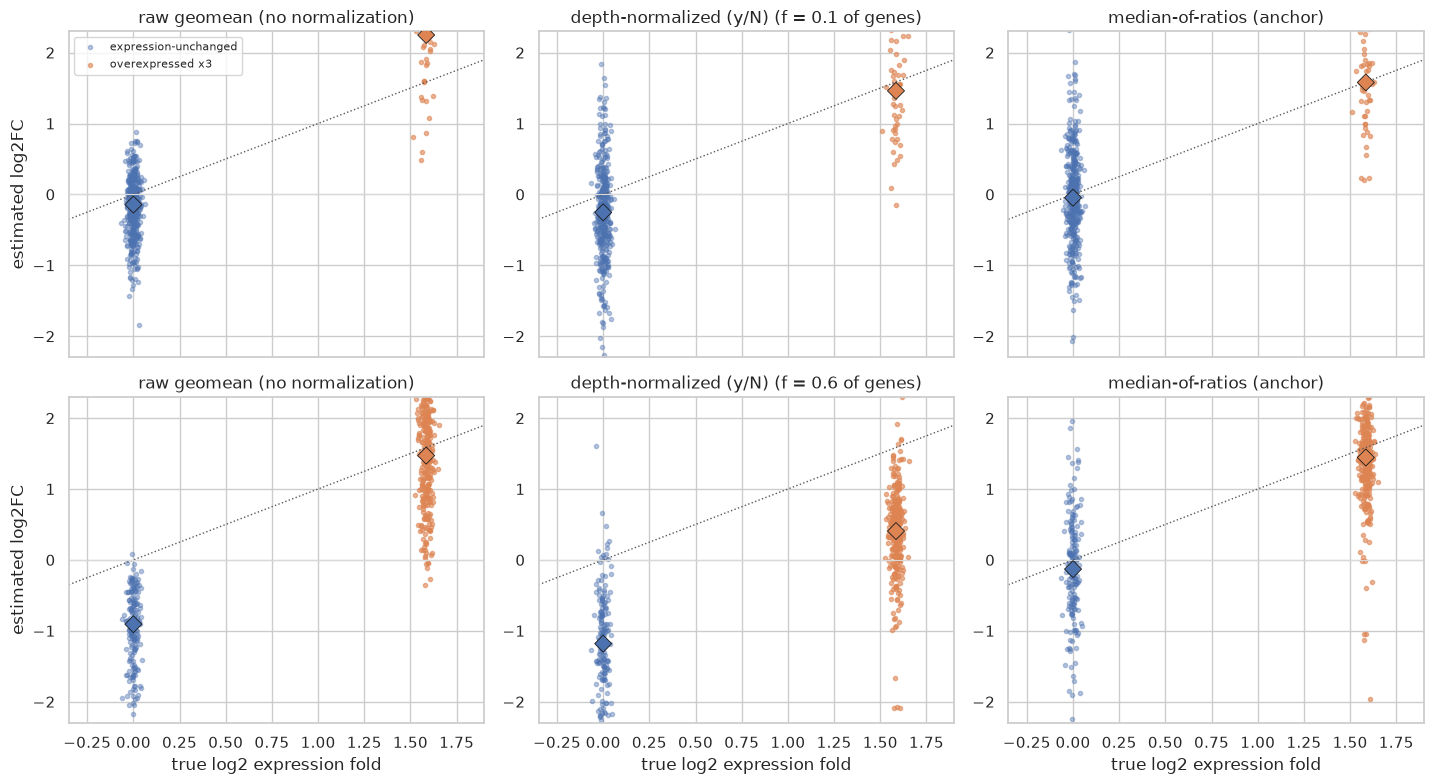

In [10]:
# Act V, figure 8: what normalization is actually doing
K4, n4 = 500, 100
pi4 = make_pi(K4, rng, sigma=1.0, sort_descending=False)
methods = ["raw", "depth", "MoR"]
titles = {"raw": "raw geomean (no normalization)", "depth": "depth-normalized (y/N)",
          "MoR": "median-of-ratios (anchor)"}


def lfc_variants(cntA, NA_, cntB, NB_):
    half = cntA.shape[0]
    out = {}
    out["raw"] = np.log2(np.exp(np.log(cntB + 0.5).mean(0))
                         / np.exp(np.log(cntA + 0.5).mean(0)))
    out["depth"] = np.log2(np.maximum(mean_proportion(cntB, NB_), 1e-12)
                           / np.maximum(mean_proportion(cntA, NA_), 1e-12))
    base = np.vstack([cntA, cntB]).astype(float)
    normed = base / mor_size_factors(base)[:, None]
    mA, mB = normed[:half].mean(0), normed[half:].mean(0)
    out["MoR"] = np.log2(np.maximum(mB, 1e-12) / np.maximum(mA, 1e-12))
    return out, base.mean(0) >= 10       # expressible genes only (sparse ones are noise)


fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.0), sharex=True)
for r_, (name, frac) in enumerate([("f = 0.1 of genes", 0.1), ("f = 0.6 of genes", 0.6)]):
    mask = np.zeros(K4, bool)
    mask[rng.choice(K4, int(round(frac * K4)), replace=False)] = True
    m = np.where(mask, 3.0, 1.0)
    piB, C = fold_pi(pi4, mask, 3.0)
    ca, ka_ = simulate_group(pi4, 100.0, n4, med_n=30_000, sigma_n=0.15,
                             rate_sigma=0.5, rng=rng)
    cb, kb_ = simulate_group(piB, 100.0, n4, census_factor=C, med_n=30_000, sigma_n=0.15,
                             rate_sigma=0.5, rng=rng)
    lv, keep = lfc_variants(ca, ka_, cb, kb_)
    tx = np.where(mask, np.log2(3.0), 0.0)[keep]
    jit = rng.normal(0.0, 0.02, int(keep.sum()))
    mk = mask[keep]
    print(f"{name}: material multiplier C = {C:.2f} | median N: A "
          f"{np.median(ka_)/1e3:.0f}k, B {np.median(kb_)/1e3:.0f}k (nominal "
          f"{30*C:.0f}k) | {keep.sum()} of {K4} genes expressible")
    for meth in methods:
        up = np.median(lv[meth][keep][mask[keep]])
        un = np.median(lv[meth][keep][~mask[keep]])
        print(f"  {meth:>5}: overexpressed {up:+.2f} | unchanged {un:+.2f}")
    for c_, meth in enumerate(methods):
        ax = axes[r_, c_]
        est = lv[meth][keep]
        ax.scatter(tx[~mk] + jit[~mk], est[~mk], s=9, alpha=0.4, color=COL_A,
                   label="expression-unchanged")
        ax.scatter(tx[mk] + jit[mk], est[mk], s=9, alpha=0.6, color=COL_B,
                   label="overexpressed x3")
        ax.scatter([0, np.log2(3)], [np.median(est[~mk]), np.median(est[mk])],
                   marker="D", s=75, c=[COL_A, COL_B], edgecolors="k",
                   linewidths=0.6, zorder=4)
        ax.plot([-0.35, 1.9], [-0.35, 1.9], color="0.35", ls=":", lw=1, zorder=1)
        ax.axhline(0, color="0.85", lw=0.8)
        ax.set(xlim=(-0.35, 1.9), ylim=(-2.3, 2.3),
               xlabel="true log2 expression fold" if r_ else None,
               ylabel="estimated log2FC" if not c_ else None,
               title=f"{titles[meth]} ({name})" if c_ == 1 else titles[meth])
        if r_ == 0 and c_ == 0:
            ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

## The map: four layers, four questions

Everything in the three notebooks resolves into a small stack. Each layer answers a
different question, with its own instruments, and each one spends its own assumption:

| layer | the question | the instruments | the assumption spent |
|---|---|---|---|
| noise | how do reads scatter around the truth? | Dirichlet-multinomial, beta-binomial, NB-GLMs, Welch variance | a dispersion structure (θ, or per-gene α) |
| geometry | where does each composition sit? | clr, ILR, ALR (log-ratios) | a zeros policy; which log-contrast basis |
| scale | at which scale are samples compared? | plain depth, median-of-ratios (DESeq2), TMM (edgeR), scran pools | majority rule, or a census/rate story about N |
| absolute | what are the true per-gene abundances? | spike-ins, housekeeping evidence, external calibration | identifiability, bought by design |

Which means identifiability comes in three grades, and it is worth being explicit about
which one a claim enjoys:

* **Free, from counts alone:** the per-group compositions and their shifts, the
  overdispersion, and the library-size distribution. Act I, plus the honest parts of
  Acts II and III ("the composition moved").
* **Anchored, once you state the anchor:** the direction of a shift (overexpressed vs
  underexpressed) and absolute fold changes, relative to the anchor. Acts IV and V.
* **Designed:** molecules. Only spike-ins or an external calibration standard provide
  that; nothing in the counts will ever provide it for free.

The three standard failure points, located and reproducible: the naive variance explodes
first (Act I); the bare transform re-expresses but never identifies, and charges rent on
sparse data in the currency of pseudocounts (Act IV); the anchor bends when the majority
moves (Act V). None of the fixes resurrect the absolute scale, because the mirror trick
and the vanishing effect are properties of the measurement process, not of any method.

## A practical checklist

1. **Simulate first.** Write the generator. Include overdispersion and depth variation
   from the start, then watch what a standard pipeline reports for a genome on which,
   provably, nothing changed.
2. **Model the noise explicitly.** Beta-binomial, Dirichlet-multinomial, per-gene
   negative-binomial GLMs, or empirical-variance tests (Welch) that absorb the
   overdispersion by construction. A nominal 5% test that fires on nine of ten unchanged
   genes is not a statistical tool; it is a smoke machine.
3. **Report relative claims in log-ratio space** (clr or ILR), and treat the zero
   policy as a stated design decision, because for sparse categories the policy *is* the
   estimate.
4. **Name your normalization anchor**, and what happens when it fails.
   Median-of-ratios stands on "most genes do not move"; plain depth stands on "N knows
   the census"; TMM and scran are cousins of the first two. The anchor is an empirical
   claim; test it, or at least say it aloud.
5. **Buy absolute claims, do not assume them.** Spike-ins or external calibration, or
   silence. Everything else in the results section is relative to whichever anchor was
   spent, and the text should say which.

## Coda: which assumption are you spending?

The tools in this story are often presented as rivals: the model people, the transform
people, the normalize people. The simulations say something friendlier and more useful.
Each occupies a layer. The layers compose: a calibrated count model inside, log-ratio
coordinates in the middle, a stated anchor on top, and, when the question is about
molecules, a designed calibration. Nothing in the stack rescues your identifiability;
everything in it spends an assumption.

And there is a cheap superpower hiding underneath, which is the whole reason these
notebooks exist. Every result in this post came out of a forty-line simulator, not from
a real dataset whose truth is unverifiable. Before trusting any pipeline on your counts,
build the generator, set θ to something honest, break the anchor on purpose, and watch
what the method says. The method that survives the sabotage has, by construction, told
you exactly which assumption it was spending all along. That is not a detail of the
analysis. That is the analysis.

**Full notebooks:** the [Dirichlet-multinomial sampler](dirichlet-multinomial-simulation.ipynb)
(noisemaking and moment checks), the [identifiability experiments](dm-overexpression-identifiability.ipynb)
(the mirror trick, the vanishing effect, anchor failures), and the [clr and
median-of-ratios field guide](clr-and-median-of-ratios-on-dm-counts.ipynb)
(logistic-normal geometry, zeros, calibration). Counts were simulated with numpy;
figures with matplotlib and seaborn.